In [ ]:
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd

sys.path.append(os.path.abspath(os.path.join('../../analysis')))

In [2]:
from xa.proc.exp import Experiment

x = Experiment(
    name="Asymmetric Run 1h",
    i1='sockshop-2023-11-05T15-27-22/asym1h/1',
    i2='sockshop-2023-11-05T15-27-22/asym1h/2',
    i3='sockshop-2023-11-05T15-27-22/asym1h/3',
    # ...
)

In [3]:
x.stats

count          mean           std           min  \
iter stat                                                                      
i1   cpu usage             10887.0  1.969115e+00  2.500635e+00  3.782000e-03   
     memory usage          10887.0  7.765605e-01  8.723021e-01  3.090000e-02   
     request latency        3600.0  7.201937e+06  1.263884e+08  1.947291e+06   
     request throughput     3600.0  1.056128e+01  3.231644e+00  1.120241e+00   
     response time       1535673.0  4.274779e+00  7.199464e+00  1.000000e-07   
i2   cpu usage             10888.0  2.504813e+00  3.627437e+00  4.093000e-03   
     memory usage          10888.0  7.738057e-01  8.782355e-01  3.049800e-02   
     request latency        3600.0  7.319090e+06  1.263470e+08  1.992610e+06   
     request throughput     3600.0  1.055982e+01  3.229311e+00  1.120701e+00   
     response time       1543763.0  4.257375e+00  7.267526e+00  1.000000e-07   
i3   cpu usage             10892.0  2.243191e+00  3.002070e+00  3.816000e-03   
     memory usage          10892.0  7.730360e-01  8.689390e-01  3.132700e-02   
     request latency        3600.0  7.366815e+06  1.263612e+08  1.992383e+06   
     request throughput     3600.0  1.055838e+01  3.226646e+00  1.120514e+00   
     response time       1543384.0  4.259415e+00  7.269099e+00  1.000000e-07   

                                  25%           50%           75%  \
iter stat                                                           
i1   cpu usage           3.629275e-01  6.612580e-01  2.599346e+00   
     memory usage        2.166850e-01  3.599850e-01  1.216578e+00   
     request latency     4.941650e+06  5.332382e+06  5.682682e+06   
     request throughput  9.074775e+00  9.114856e+00  1.103847e+01   
     response time       7.520700e-05  2.066210e-04  1.510313e+01   
i2   cpu usage           3.640828e-01  7.858780e-01  2.960062e+00   
     memory usage        1.639510e-01  3.627160e-01  1.186410e+00   
     request latency     5.014405e+06  5.411280e+06  5.786556e+06   
     request throughput  9.072426e+00  9.113821e+00  1.103612e+01   
     response time       7.690800e-05  2.094200e-04  1.510319e+01   
i3   cpu usage           3.585200e-01  7.297130e-01  2.803992e+00   
     memory usage        1.741820e-01  3.462420e-01  1.210847e+00   
     request latency     5.026141e+06  5.418148e+06  5.785970e+06   
     request throughput  9.073640e+00  9.114137e+00  1.103590e+01   
     response time       7.700700e-05  2.089200e-04  1.510292e+01   

                                  max  
iter stat                              
i1   cpu usage           1.370135e+01  
     memory usage        5.272011e+00  
     request latency     7.587888e+09  
     request throughput  2.291810e+01  
     response time       5.241188e+02  
i2   cpu usage           2.880663e+01  
     memory usage        5.290013e+00  
     request latency     7.585141e+09  
     request throughput  2.294744e+01  
     response time       3.113000e+02  
i3   cpu usage           1.970903e+01  
     memory usage        5.280734e+00  
     request latency     7.585755e+09  
     request throughput  2.292257e+01  
     response time       3.158719e+02

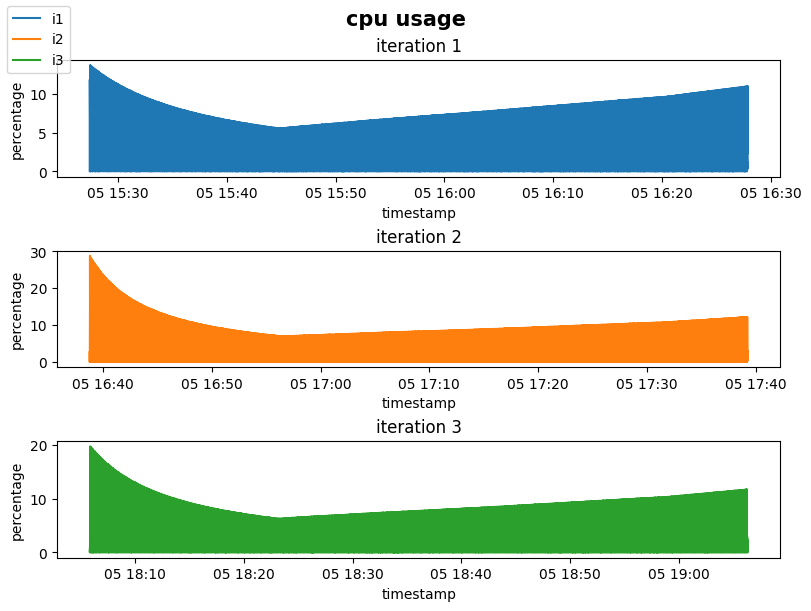

In [41]:
from xa.draw.plot import Figure, Pairwise

Figure(1, # ncols
    Pairwise(x=x.i1.metric.cpu.usage.TS, y=x.i1.metric.cpu.usage.V, label='i1', title='iteration 1', xlabel='timestamp', ylabel='percentage'),
    Pairwise(x=x.i2.metric.cpu.usage.TS, y=x.i2.metric.cpu.usage.V, label='i2', title='iteration 2', xlabel='timestamp', ylabel='percentage'),
    Pairwise(x=x.i3.metric.cpu.usage.TS, y=x.i3.metric.cpu.usage.V, label='i3', title='iteration 3', xlabel='timestamp', ylabel='percentage'),
    title='cpu usage', title_props=dict(fontsize=15, fontweight='bold'),
    subplots_props=dict(layout='constrained', figsize=(8,6)),
).fig

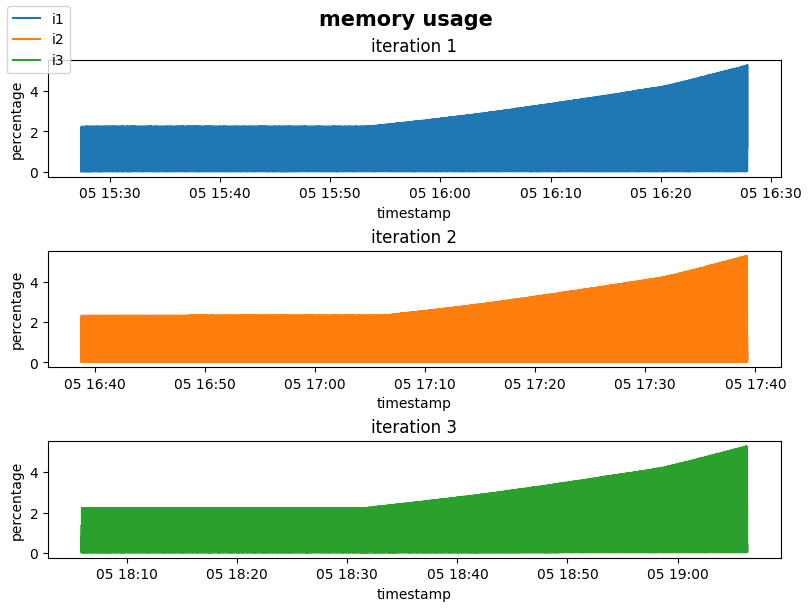

In [42]:
Figure(1, # ncols
    Pairwise(x=x.i1.metric.memory.usage.TS, y=x.i1.metric.memory.usage.V, label='i1', title='iteration 1', xlabel='timestamp', ylabel='percentage'),
    Pairwise(x=x.i2.metric.memory.usage.TS, y=x.i2.metric.memory.usage.V, label='i2', title='iteration 2', xlabel='timestamp', ylabel='percentage'),
    Pairwise(x=x.i3.metric.memory.usage.TS, y=x.i3.metric.memory.usage.V, label='i3', title='iteration 3', xlabel='timestamp', ylabel='percentage'),
    title='memory usage', title_props=dict(fontsize=15, fontweight='bold'),
    subplots_props=dict(layout='constrained', figsize=(8,6)),
).fig

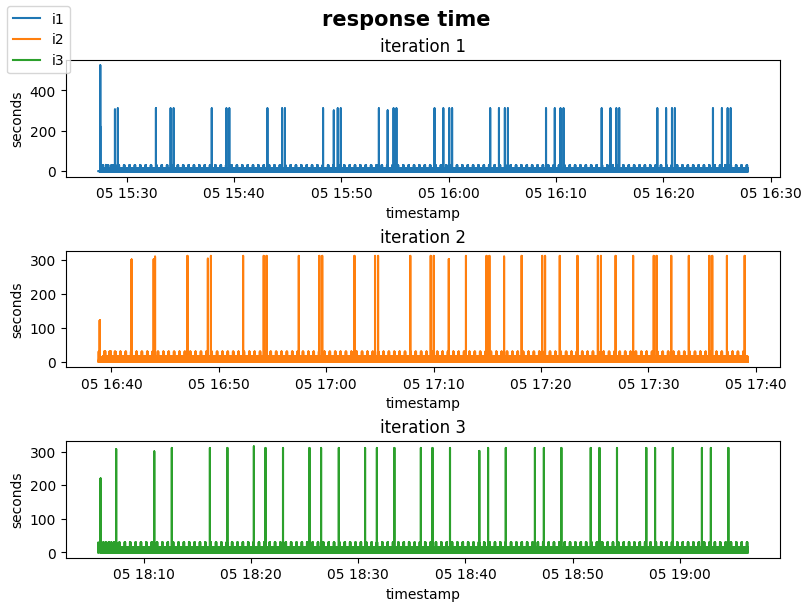

In [43]:
Figure(1, # ncols
    Pairwise(x=x.i1.metric.response.time.TS, y=x.i1.metric.response.time.V, label='i1', title='iteration 1', xlabel='timestamp', ylabel='seconds'),
    Pairwise(x=x.i2.metric.response.time.TS, y=x.i2.metric.response.time.V, label='i2', title='iteration 2', xlabel='timestamp', ylabel='seconds'),
    Pairwise(x=x.i3.metric.response.time.TS, y=x.i3.metric.response.time.V, label='i3', title='iteration 3', xlabel='timestamp', ylabel='seconds'),
    title='response time', title_props=dict(fontsize=15, fontweight='bold'),
    subplots_props=dict(layout='constrained', figsize=(8,6)),
).fig

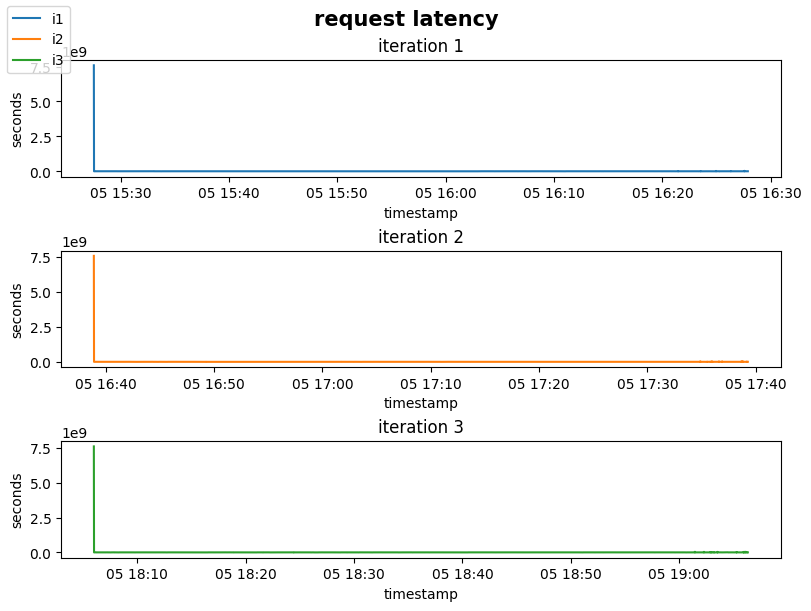

In [44]:
Figure(1, # ncols
    Pairwise(x=x.i1.metric.request.latency.TS, y=x.i1.metric.request.latency.V, label='i1', title='iteration 1', xlabel='timestamp', ylabel='seconds'),
    Pairwise(x=x.i2.metric.request.latency.TS, y=x.i2.metric.request.latency.V, label='i2', title='iteration 2', xlabel='timestamp', ylabel='seconds'),
    Pairwise(x=x.i3.metric.request.latency.TS, y=x.i3.metric.request.latency.V, label='i3', title='iteration 3', xlabel='timestamp', ylabel='seconds'),
    title='request latency', title_props=dict(fontsize=15, fontweight='bold'),
    subplots_props=dict(layout='constrained', figsize=(8,6)),
).fig

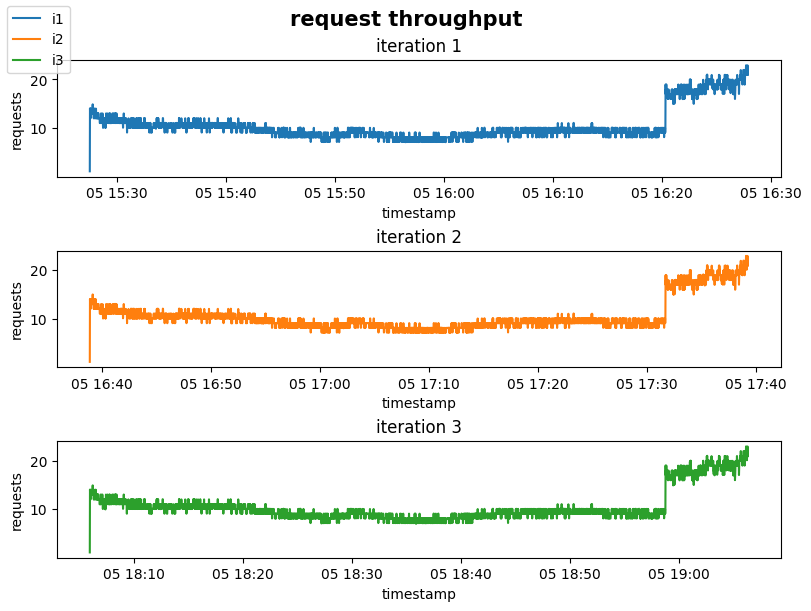

In [46]:
Figure(1, # ncols
    Pairwise(x=x.i1.metric.request.throughput.TS, y=x.i1.metric.request.throughput.V, label='i1', title='iteration 1', xlabel='timestamp', ylabel='requests'),
    Pairwise(x=x.i2.metric.request.throughput.TS, y=x.i2.metric.request.throughput.V, label='i2', title='iteration 2', xlabel='timestamp', ylabel='requests'),
    Pairwise(x=x.i3.metric.request.throughput.TS, y=x.i3.metric.request.throughput.V, label='i3', title='iteration 3', xlabel='timestamp', ylabel='requests'),
    title='request throughput', title_props=dict(fontsize=15, fontweight='bold'),
    subplots_props=dict(layout='constrained', figsize=(8,6)),
).fig